# **Tutorial Topic Modeling - CARMA 2024**

![image info](https://pbs.twimg.com/media/GIKiC8jWkAAdxzy?format=jpg&name=4096x4096)

<hr>

## **Setup**

### **Imports**

In [ ]:
# These might take a minute or two!
%pip install accelerate transformers bertopic top2vec[sentence_transformers]
%pip install -i https://pypi.org/simple/ bitsandbytes

In [2]:
import os
from torch import cuda
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import timeit
import platform
from pathlib import Path
from datetime import datetime

# Tokenization tools
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from string import punctuation
import re

# Scikit-Learn
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import CountVectorizer

# Coherence
import gensim.corpora as corpora
from gensim.models.coherencemodel import CoherenceModel
from gensim.utils import tokenize

# Word Clouds
from wordcloud import WordCloud

In [3]:
device = f'cuda:{cuda.current_device()}' if cuda.is_available() else 'cpu'
print(device)

cuda:0


### **Globals**

In [14]:
seed          : int  = 42
limit_dataset : int  = 10000  # 'None' for no limiting
llm_model_id  : str  = 'NousResearch/Meta-Llama-3-8B-Instruct'
from_colab    : bool = True

### **Classes**
Utility classes definining coherence metrics for the different models (BERT, Top2Vec) and word cloud generation.

In [10]:
class Metrics():

  def bert_coherence(self, sentences, topics):

    # Preprocess Documents
    documents = pd.DataFrame({
        "Document": sentences[0:10000],
        "ID": range(len(sentences[0:10000])),
        "Topic": topics}
    )
    documents_per_topic = documents.groupby(['Topic'], as_index=False).agg({'Document': ' '.join})
    cleaned_docs = BERTopic_model._preprocess_text(documents_per_topic.Document.values)

    # Extract vectorizer and analyzer from BERTopic
    vectorizer = BERTopic_model.vectorizer_model
    analyzer = vectorizer.build_analyzer()

    # Extract features for Topic Coherence evaluation
    words = vectorizer.get_feature_names_out()
    tokens = [analyzer(doc) for doc in cleaned_docs]
    dictionary = corpora.Dictionary(tokens)
    corpus = [dictionary.doc2bow(token) for token in tokens]
    topic_words = [[words for words, _ in BERTopic_model.get_topic(topic)] for topic in range(len(set(topics)))]

    # Evaluate
    coherence_model = CoherenceModel(
        topics=topic_words,
        texts=tokens,
        corpus=corpus,
        dictionary=dictionary,
        coherence='c_v'
    )
    coherence = coherence_model.get_coherence()
    return coherence

  def t2v_coherence(self, sentences, topics):
      tokenized = [list(tokenize(doc)) for doc in sentences]
      id2word = corpora.Dictionary(tokenized)
      corpus = [id2word.doc2bow(text) for text in tokenized]

      # make sure you grab the topic words from the topic model and convert them to a list
      coherence_model = CoherenceModel(
          topics = topics,
          texts=tokenized,
          corpus=corpus,
          dictionary=id2word,
          coherence='c_v',
          topn=10
      )
      coherence = coherence_model.get_coherence()
      return coherence

class AllWordClouds():

    def lda_wordcloud(self, topic, lda_model):
        wordcloud = WordCloud(background_color="white", max_words=1000, contour_width=3, contour_color='steelblue')
        texts = [x[0] for x in lda_model.show_topic(topic)]
        long_string = ','.join(texts)
        wordcloud.generate(long_string)

        return wordcloud.to_image()


### **Data table formatter**
Enable colab `data_table`.

In [7]:
from google.colab import data_table
#data_table.enable_dataframe_formatter()
data_table.disable_dataframe_formatter()

<hr>

## **Data**
In this section, we will download, import and preprocess the data needed for the analysis.

### **Data Download**
Download the data. If `from_colab` is set to `True`, this cell will automatically clone the repository into the colab environment. The repository contains data and useful resources.

In [11]:
if from_colab:
    if Path("/content/TopicModelingLab").is_dir():
        %cd "/content/TopicModelingLab"
        !git pull
    else:
        %cd "/content"
        !git clone https://github.com/istat-methodology/TopicModelingLab.git
    path = '/content/TopicModelingLab/dataset'
else:
    path = 'dataset'

/content
Cloning into 'CARMA2024'...
remote: Enumerating objects: 148, done.
remote: Counting objects: 100% (148/148), done.
remote: Compressing objects: 100% (135/135), done.
remote: Total 148 (delta 66), reused 44 (delta 9), pack-reused 0
Receiving objects: 100% (148/148), 29.27 MiB | 13.54 MiB/s, done.
Resolving deltas: 100% (66/66), done.


### **Data Import**
After the data is downloaded, we need to import it as a `pd.DataFrame`.

In [12]:
tutorial_dataset  = pd.read_csv(f"{path}/tutorial_dataset_covid_100k.csv")
tutorial_dataset.head()

,date,text
0,2020-05-08,mi può spiegare cosa c entra un bonus fatto pe...
1,2020-02-14,la commissione dice che il reddito di cittadin...
2,2020-05-14,jeperego per far girare l economia
3,2020-03-29,questi sono gli economisti per cui siccome la ...
4,2020-05-16,urgente una mia compagna di scuola deve fare u...


Check the shape of the data frame.

In [13]:
tutorial_dataset.shape

(100000, 2)

Plot the Tweet volume distribution over time.

In [ ]:
tweet_counts = tutorial_dataset.groupby('date').count().reset_index()

fig = px.line(tweet_counts, x='date', y='text', title="Tweet Distribution over the Time Range", labels={'date': 'Date', 'text': 'N Tweets'})
fig.update_layout(xaxis=dict(tickangle=45))

fig.show()

### **Data Pre-processing**

#### **General pre-processing**
Extract a sample of sentences from the dataframe. In order to run the tutorial scripts in real time we limit our analysis to `limit_dataset` (10,000) sentences

In [15]:
if limit_dataset is not None:
  sentences = [text for text in tutorial_dataset.sample(limit_dataset, random_state=seed).text]
else:
  sentences = [text for text in tutorial_dataset.text]

print(f"N. of sentences: {len(sentences)}")

N. of sentences: 10000


Every sentence corresponds to a Tweet. We can inspect the individual Tweets by indexing the `sentences` list. For example, here is the 166th Tweet in the list:

In [18]:
print(sentences[165])

mastrotitta quelli per cui l unico consumo ammissibile in questo momento così difficile sarebbe quello di pane e acqua quegli stessi che poi si lamentano della disoccupazione generata dal crollo dei consumi 


#### **Pre-processing for Traditional Methods**
Before training our models, we need to pre-process the data to make it suitable for analysis.

##### **Stop words initialization**

In [19]:
nltk.download('stopwords')
nltk.download('punkt')

stop_words = set(stopwords.words('italian'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Visualize some of the stopwords.

In [24]:
print(list(stop_words)[0:19])

['mio', 'aveva', 'avesti', 'essendo', 'staremmo', 'stessero', 'stavi', 'facevi', 'fossero', 'tutti', 'avevamo', 'abbiamo', 'stesse', 'le', 'avrei', 'dall', 'dagl', 'avremmo', 'noi']


##### **Tokenization and stopwords removal**
In order for the texts to be processed by the algorithms, we need to tokenize them, i.e. turning strings into indices. We will also remove stopwords (like articles and words that do not impact a sentence's meaning) in order to obtain clean topics.

In [26]:
clean_sentences = []

for document in sentences:
    tokens = word_tokenize(document)
    filtered_tokens = [word for word in tokens if word.lower() not in stop_words and word.isalpha()]
    clean_sentences.append(filtered_tokens)

Visualize a Tweet before and after cleaning:

In [40]:
tweet_idx = 25

print(f'Original Text:\n{sentences[tweet_idx]}\n')
print(f'Clean Text:\n{clean_sentences[tweet_idx]}')

Original Text:
debito e fiducia il difficile rapporto tra la cicala italiana e le formica tedesca di albertobisin micheleboldrin bruscosandro clementi gl andreamoro e giulio zanella [] 

Clean Text:
['debito', 'fiducia', 'difficile', 'rapporto', 'cicala', 'italiana', 'formica', 'tedesca', 'albertobisin', 'micheleboldrin', 'bruscosandro', 'clementi', 'gl', 'andreamoro', 'giulio', 'zanella']


##### **Bag-Of-Words (BOW) via Gensim: construction of dictionary and term-document matrix**
Both LDA and HDP work with bag-of-words (BOW), i.e., documents are represented in a way in which the order of words does not matter. The dictionary (or vocabulary) represents the set of unique words in the corpus.



In [30]:
dictionary = corpora.Dictionary(clean_sentences)
corpus_bow = [dictionary.doc2bow(t) for t in clean_sentences]

Explore the dictionary object.

In [35]:
type(dictionary)

gensim.corpora.dictionary.Dictionary

We can access the dictionary to obtain the token relative to a specific word.

In [34]:
dictionary.token2id['giovani']

169

Compare to the original text to the clean text and the tokenized text.

In [39]:
tweet_idx = 1200

print(f'Original Text:\n{sentences[tweet_idx]}\n')
print(f'Clean Text:\n{clean_sentences[tweet_idx]}\n')
print(f'Tokenized Text:\n{corpus_bow[tweet_idx]}')

Original Text:
banche centrali in azione mercati nel panico [] 

Clean Text:
['banche', 'centrali', 'azione', 'mercati', 'panico']

Tokenized Text:
[(12, 1), (148, 1), (1063, 1), (2742, 1), (8158, 1)]


<hr>

## **A. Traditional Topic Modeling Algorithms**
In this section, we will explore traditional topic modeling algorithms such as Latent Dirichlet Allocation (LDA), Hierarchical Dirichlet Process (HDP), and Non-negative Matrix Factorization (NMF).

### **Latent Dirichlet Allocation (LDA)**

In [41]:
from gensim.models import LdaModel

Latent Dirichlet Allocation (LDA) is a generative probabilistic model that assumes documents to be mixtures of topics, and topics to be mixtures of words.

LDA involves the following steps:
1. **Parameter Initialization**: LDA initializes the topics, the topic distribution for each document, and the word distribution for each topic.
2. **Training**: Using an iterative process (usually Gibbs sampling or variational inference), LDA refines these distributions to better fit the observed data.
3. **Topic Inference**: After several iterations, LDA infers the topic distribution for each document and the word distribution for each topic.

In LDA, the number of latent topics to be extracted needs to be defined *a priori*.

#### **Model training**
To train an LDA model, we need to specify *a priori* the number of latent topics we want to extract using the `num_topics` argument in gensim's `LdaModel` class. The `gensim` library also contains a `LdaMulticore` class for faster processing.

In [50]:
passes = 10
num_topics = 20

lda_model = LdaModel(
    corpus=corpus_bow,
    id2word=dictionary,
    passes=passes,
    num_topics=num_topics,
    random_state=seed
)

#### **Topic visualization**
Visualize the extracted topics using the `print_topics()` method.

In [51]:
for idx, topic in lda_model.print_topics():
    print(f"Topic: {idx} \nWords: {topic}\n")

Topic: 0 
Words: 0.012*"coronavirus" + 0.011*"costi" + 0.009*"oggi" + 0.009*"borsa" + 0.009*"economia" + 0.008*"covid" + 0.008*"vuole" + 0.007*"news" + 0.007*"italiani" + 0.007*"milano"

Topic: 1 
Words: 0.021*"banche" + 0.021*"economia" + 0.017*"coronavirus" + 0.013*"italia" + 0.012*"covid" + 0.010*"crisi" + 0.010*"economica" + 0.009*"banca" + 0.009*"governo" + 0.009*"emergenza"

Topic: 2 
Words: 0.026*"euro" + 0.017*"mila" + 0.012*"coronavirus" + 0.009*"cassa" + 0.008*"bonus" + 0.008*"s" + 0.008*"famiglie" + 0.007*"m" + 0.007*"emergenza" + 0.007*"covid"

Topic: 3 
Words: 0.053*"debito" + 0.023*"mes" + 0.017*"pubblico" + 0.013*"ue" + 0.012*"solo" + 0.010*"fare" + 0.009*"italia" + 0.008*"cosa" + 0.008*"bce" + 0.008*"italiani"

Topic: 4 
Words: 0.013*"risparmi" + 0.011*"mes" + 0.009*"italia" + 0.009*"francia" + 0.009*"cittadini" + 0.008*"tanti" + 0.008*"germania" + 0.008*"notizia" + 0.008*"tedeschi" + 0.007*"scuole"

Topic: 5 
Words: 0.020*"economia" + 0.011*"vendite" + 0.010*"stipendio

To visualize the topics extracted by the LDA, we can plot some *wordclouds*.

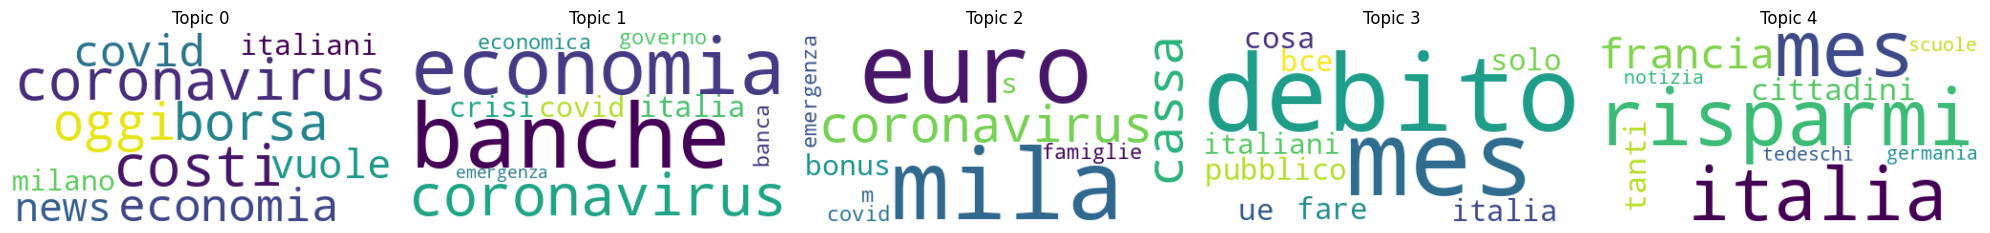

In [52]:
N = 5

wc_lda = AllWordClouds()

fig, axes = plt.subplots(1, N, figsize=(20, 4))

for i in range(N):
    wc = wc_lda.lda_wordcloud(i, lda_model)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].axis('off')
    axes[i].set_title(f'Topic {i}')

plt.tight_layout()
plt.show()

#### **Model coherence**

In [54]:
coherence_model = CoherenceModel(model=lda_model, texts=clean_sentences, dictionary=dictionary, coherence='c_v')
coherence_score = coherence_model.get_coherence()

print("LDA Model Coherence: ", round(coherence_score, 5))

LDA Model Coherence:  0.35332


<hr>

### **Hierarchical Dirichlet Process (HDP)**

In [55]:
from gensim.models import HdpModel

Hierarchical Dirichlet Process (HDP) is a non-parametric Bayesian approach to topic modeling. Unlike LDA, HDP automatically determines the number of topics based on the data.

HDP involves the following steps:
1. **Initialization**: HDP starts with an initial guess on the topic distribution.
2. **Iterative Refinement**: Using a hierarchical process, HDP refines the topic distribution at both the document and corpus levels.
3. **Dynamic Topic Adjustment**: HDP adjusts the number of topics dynamically as more data is processed.


####**Model training**
Differently from LDA, in HDP we do not need to specify the number of topics to extract *a priori*. By default, `HdpModel` will always produce 150 topics (unless you change the argument `T`) and order them by importance, measured by the `alpha` parameter.

In [ ]:
hdp_model = HdpModel(
    corpus=corpus_bow,
    id2word=dictionary,
    random_state=seed
)

#### **Topic visualization**
Visualize the extracted topics using the `print_topics()` method. Visualize the first 30 topics for convenience.

In [77]:
for idx, topic in hdp_model.print_topics(num_topics=30):
    print(f"Topic: {idx} \nWords: {topic}\n")

Topic: 0 
Words: 0.006*economia + 0.006*italia + 0.005*lavoro + 0.005*debito + 0.004*tasse + 0.004*senza + 0.004*italiani + 0.004*mes + 0.004*soldi + 0.004*reddito

Topic: 1 
Words: 0.005*economia + 0.004*debito + 0.004*italia + 0.003*euro + 0.003*banche + 0.003*coronavirus + 0.003*ora + 0.003*soldi + 0.003*governo + 0.002*mes

Topic: 2 
Words: 0.003*economia + 0.003*italia + 0.003*tasse + 0.002*senza + 0.002*debito + 0.002*stato + 0.002*lavoro + 0.002*italiani + 0.002*governo + 0.002*euro

Topic: 3 
Words: 0.003*economia + 0.003*spread + 0.003*lagarde + 0.002*italia + 0.002*tasse + 0.002*coronavirus + 0.002*draghi + 0.002*anni + 0.002*crisi + 0.002*solo

Topic: 4 
Words: 0.003*economia + 0.002*tasse + 0.002*italia + 0.002*governo + 0.002*fare + 0.002*poi + 0.002*spese + 0.002*debito + 0.002*stipendio + 0.001*soldi

Topic: 5 
Words: 0.003*economia + 0.002*soldi + 0.002*italia + 0.002*cosa + 0.001*mes + 0.001*lavoro + 0.001*conte + 0.001*ue + 0.001*debito + 0.001*covid

Topic: 6 
Words:

To visualize the topics extracted by the LDA, we can plot some *wordclouds*.

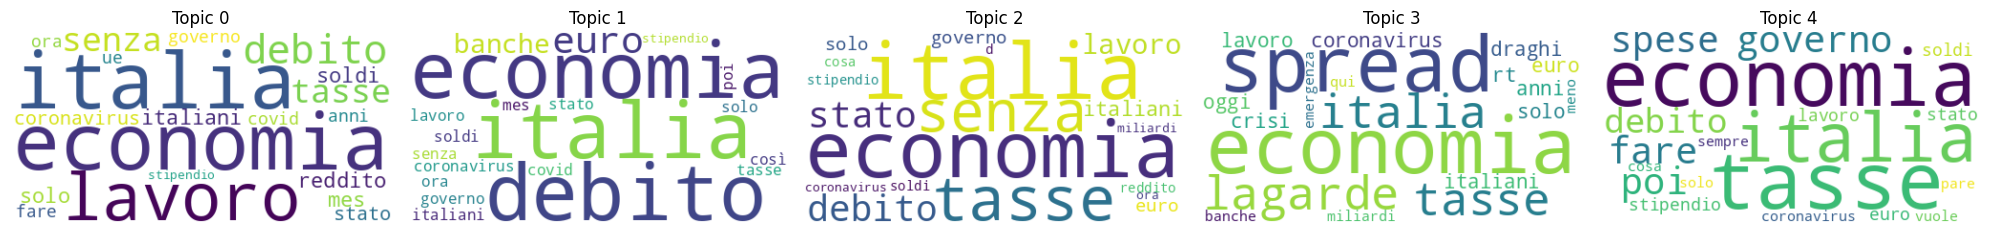

In [78]:
N = 5

wc_hdp = AllWordClouds()

fig, axes = plt.subplots(1, N, figsize=(20, 4))

for i in range(N):
    wc = wc_hdp.lda_wordcloud(i, hdp_model)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].axis('off')
    axes[i].set_title(f'Topic {i}')

plt.tight_layout()
plt.show()

#### **Model coherence**

In [79]:
coherence_model = CoherenceModel(model=hdp_model, texts=clean_sentences, dictionary=dictionary, coherence='c_v')
coherence_score = coherence_model.get_coherence()

print("HDP Model Coherence: ", round(coherence_score, 5))

HDP Model Coherence:  0.4885


<hr>

### **Non-Negative Matrix Factorization (NMF)**

In [80]:
from gensim.models import Nmf

Non-negative Matrix Factorizzation (NMF) is a non-probabilistic technique, particularly suitable for large, sparse datasets. Unlike probabilistic models like LDA and HDP, NMF is a linear algebra-based method that decomposes the document-term matrix into two lower-dimensional matrices, one representing the topics and the other representing the topic distribution for each document.

NMF involves the following steps:
1. **Matrix Decomposition**: NMF decomposes the document-term matrix into two non-negative matrices.
2. **Iterative Optimization**: Using iterative optimization techniques, NMF refines these matrices to minimize the reconstruction error.
3. **Topic Extraction**: The resulting matrices are used to extract the topics and their distribution across documents.

Likewise LDA, NMF requires the number of topics to extract to be defined *a priori*.

#### **Model training**

In [81]:
num_topics = 20

nmf_model = Nmf(
    corpus=corpus_bow,
    id2word=dictionary,
    num_topics=num_topics,
    random_state=seed
)

#### **Topic visualization**
Visualize the extracted topics using the `print_topics()` method.

In [82]:
for idx, topic in nmf_model.print_topics():
    print(f"Topic: {idx} \nWords: {topic}\n")

Topic: 0 
Words: 0.054*"quando" + 0.020*"coronavirus" + 0.011*"soldi" + 0.010*"solo" + 0.010*"dopo" + 0.006*"acquistare" + 0.006*"famiglie" + 0.005*"spendere" + 0.004*"giorno" + 0.004*"famiglia"

Topic: 1 
Words: 0.050*"governo" + 0.047*"senza" + 0.018*"mes" + 0.011*"covid" + 0.008*"miliardi" + 0.007*"banche" + 0.007*"ue" + 0.007*"condizioni" + 0.006*"ogni" + 0.005*"conte"

Topic: 2 
Words: 0.036*"no" + 0.015*"economia" + 0.013*"vuole" + 0.012*"poi" + 0.011*"banche" + 0.009*"così" + 0.008*"sempre" + 0.008*"spese" + 0.007*"dice" + 0.006*"fatto"

Topic: 3 
Words: 0.027*"s" + 0.026*"tasse" + 0.022*"m" + 0.011*"debito" + 0.010*"prezzi" + 0.009*"rt" + 0.007*"soldi" + 0.007*"niente" + 0.007*"dice" + 0.006*"dopo"

Topic: 4 
Words: 0.121*"italia" + 0.009*"europa" + 0.007*"paese" + 0.007*"covid" + 0.005*"economia" + 0.005*"d" + 0.004*"può" + 0.004*"fa" + 0.003*"germania" + 0.003*"grecia"

Topic: 5 
Words: 0.033*"debito" + 0.032*"anni" + 0.030*"pubblico" + 0.007*"stati" + 0.007*"essere" + 0.006*

To visualize the topics extracted by the LDA, we can plot some *wordclouds*.

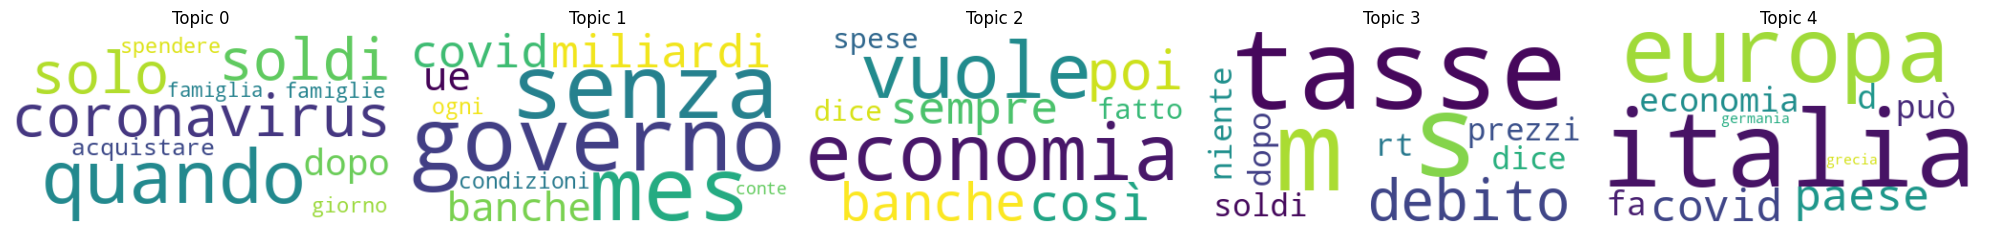

In [83]:
N = 5

wc_nmf = AllWordClouds()

fig, axes = plt.subplots(1, N, figsize=(20, 4))

for i in range(N):
    wc = wc_nmf.lda_wordcloud(i, nmf_model)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].axis('off')
    axes[i].set_title(f'Topic {i}')

plt.tight_layout()
plt.show()

#### **Model coherence**

In [84]:
coherence_model = CoherenceModel(model=nmf_model, texts=clean_sentences, dictionary=dictionary, coherence='c_v')
coherence_score = coherence_model.get_coherence()
print("NMF Model Metrics (Coherence): ", round(coherence_score, 5))

NMF Model Metrics (Coherence):  0.37441


<hr>

## **B. Clustering Algorithms on Embedding Spaces**
Clustering algorithms on embedding spaces, such as Top2Vec and BERTopic, leverage neural network-based embeddings to discover topics in text data. Unlike traditional topic modeling algorithms like LDA, HDP and NMF, which rely on statistical methods to discover topics in a corpus, these newer approaches use dense vector representations to capture semantic similarities more effectively.

### **Top2Vec**

In [86]:
from top2vec import Top2Vec

Top2Vec is an algorithm that simultaneously learns the topic representations and the word embeddings. By mapping documents to a continuous vector space, Top2Vec identifies clusters of documents that share similar themes without requiring a pre-defined number of topics. This approach allows for the discovery of natural and meaningful topics directly from the data.

Top2Vec involves the following steps:
1. **Embedding Creation**: Top2Vec uses word embeddings to create document vectors.
2. **Dimensionality Reduction**: The document vectors are reduced to a lower-dimensional space using techniques like UMAP.
3. **Clustering**: The reduced vectors are clustered to identify topics.
4. **Topic Words Identification**: The algorithm finds words that are closest to the cluster centroids, representing the topics.


#### **Model training**

In [ ]:
# choose the embedding model
embeddings = 'distiluse-base-multilingual-cased'

# train the Top2Vec model
min_word_count = 5

t2v_model = Top2Vec(
    documents=sentences,
    embedding_model=embeddings,
    min_count=min_word_count
)

#### **Topic visualization**

In [125]:
topics = t2v_model.get_topics()

words_list = topics[0]
scores_list = topics[1]
topic_num_list = topics[2]
topic_size_list, _ = t2v_model.get_topic_sizes()

print(f'Top2Vec extracted {t2v_model.get_num_topics()} topics.\n')

for words, scores, topic_num in zip(words_list, scores_list, topic_num_list):
    df_vis = pd.DataFrame({'word': words, 'score': scores})
    topic_size = topic_size_list[topic_num]
    print(f'Topic {topic_num} ({topic_size} Tweets):')
    print(df_vis.head(10), '\n')

Top2Vec extracted 7 topics.

Topic 0 (8637 Tweets):
             word     score
0      economista  0.274759
1        economie  0.265698
2          brexit  0.265585
3      economisti  0.262423
4       economist  0.259815
5        economia  0.259424
6         fiscale  0.256672
7       econopoly  0.251881
8  macroeconomico  0.241354
9       economici  0.240812 

Topic 1 (352 Tweets):
              word     score
0        eurogroup  0.376984
1       eurogruppo  0.373665
2         eurozona  0.334148
3         eurobond  0.323337
4        eurobonds  0.319986
5  gualtierieurope  0.298996
6          europea  0.296789
7             euro  0.296616
8          europei  0.293547
9         european  0.293312 

Topic 2 (227 Tweets):
            word     score
0    coronavirus  0.275675
1  coronarovirus  0.274783
2          morto  0.272862
3      mortalita  0.269128
4        decessi  0.260868
5          muore  0.246996
6          morti  0.233802
7         morire  0.232875
8         cancro  0.230595
9  

To visualize the topics extracted by the LDA, we can plot some *wordclouds*.

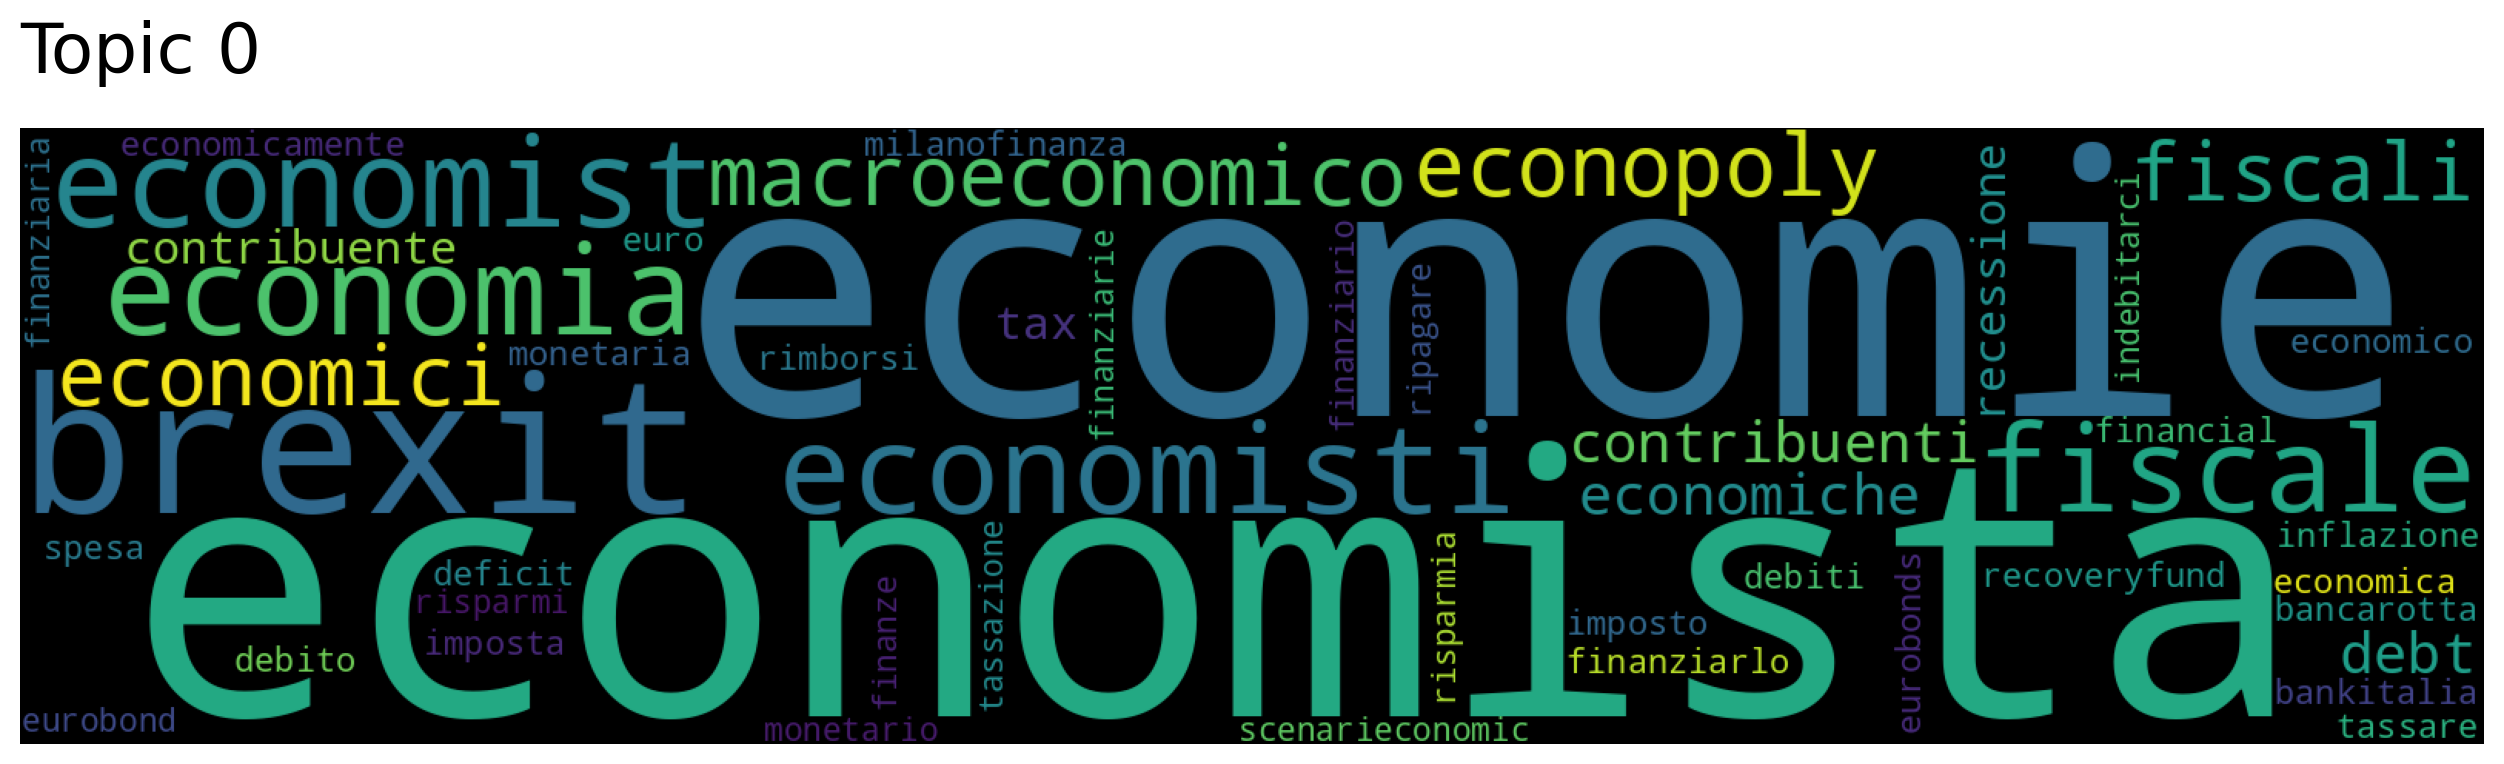

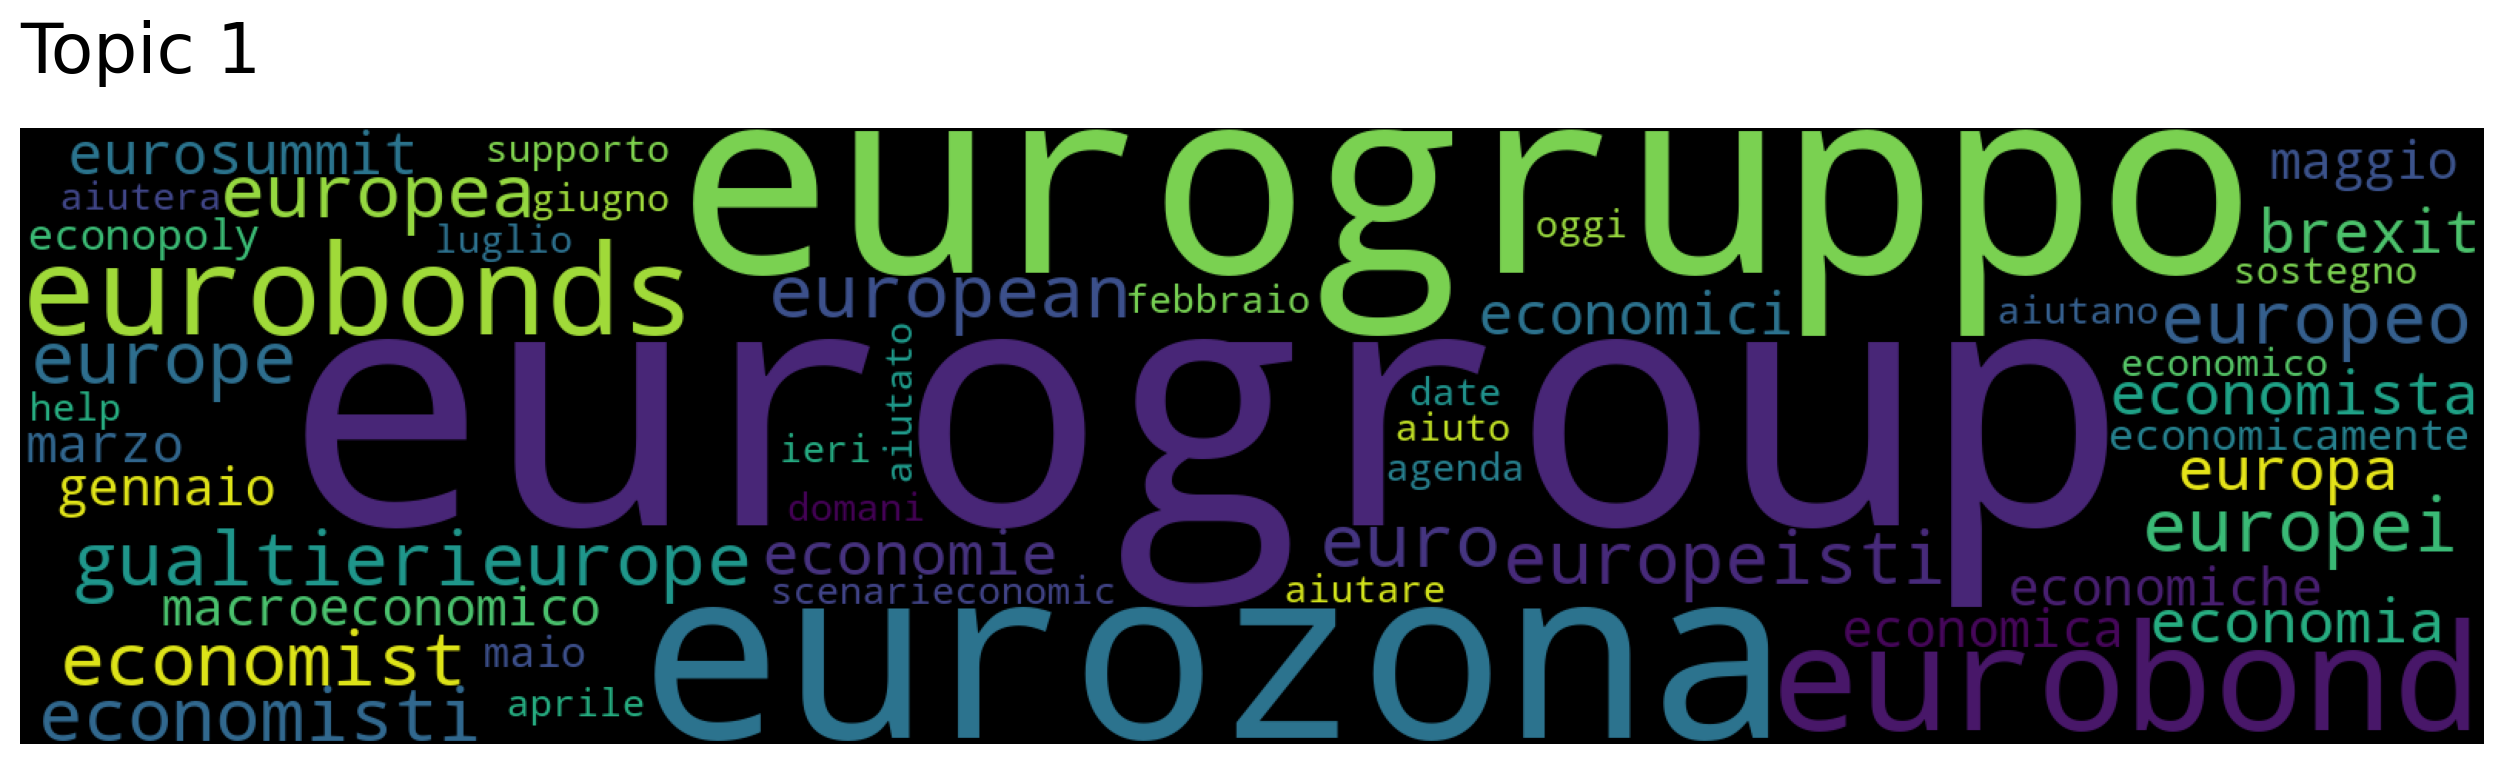

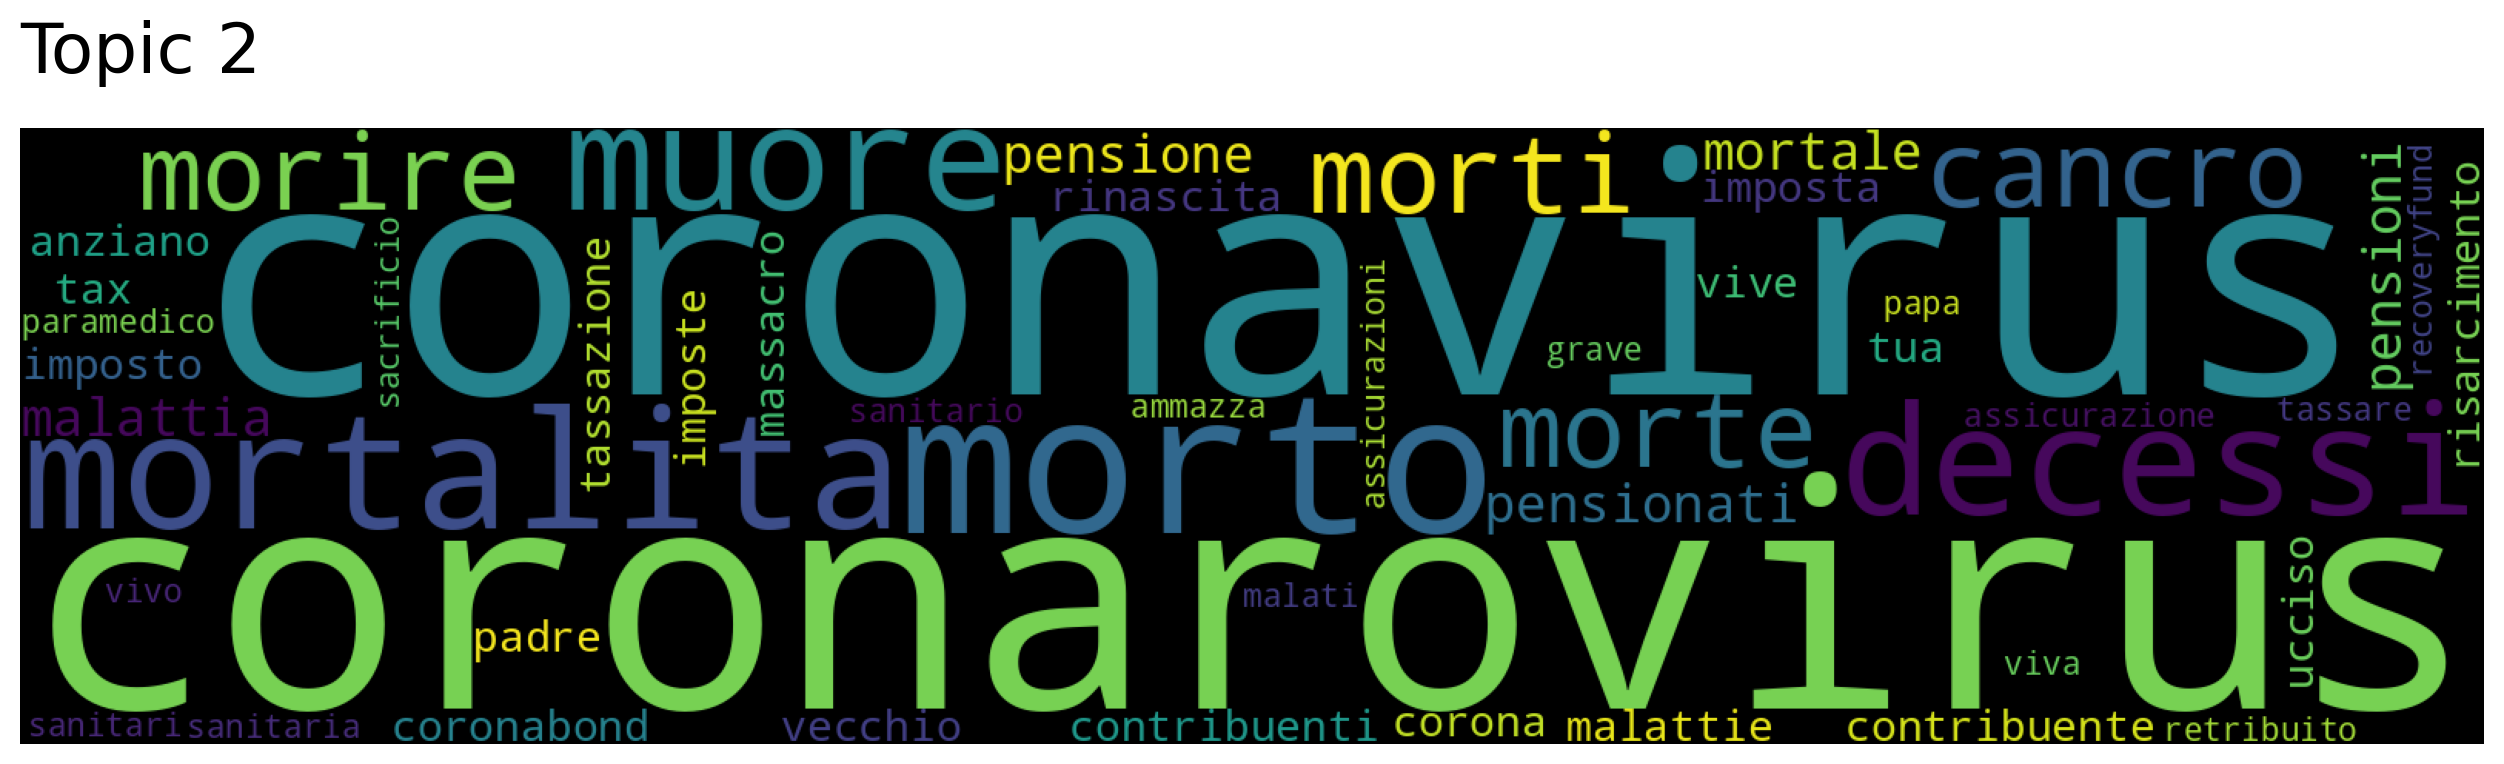

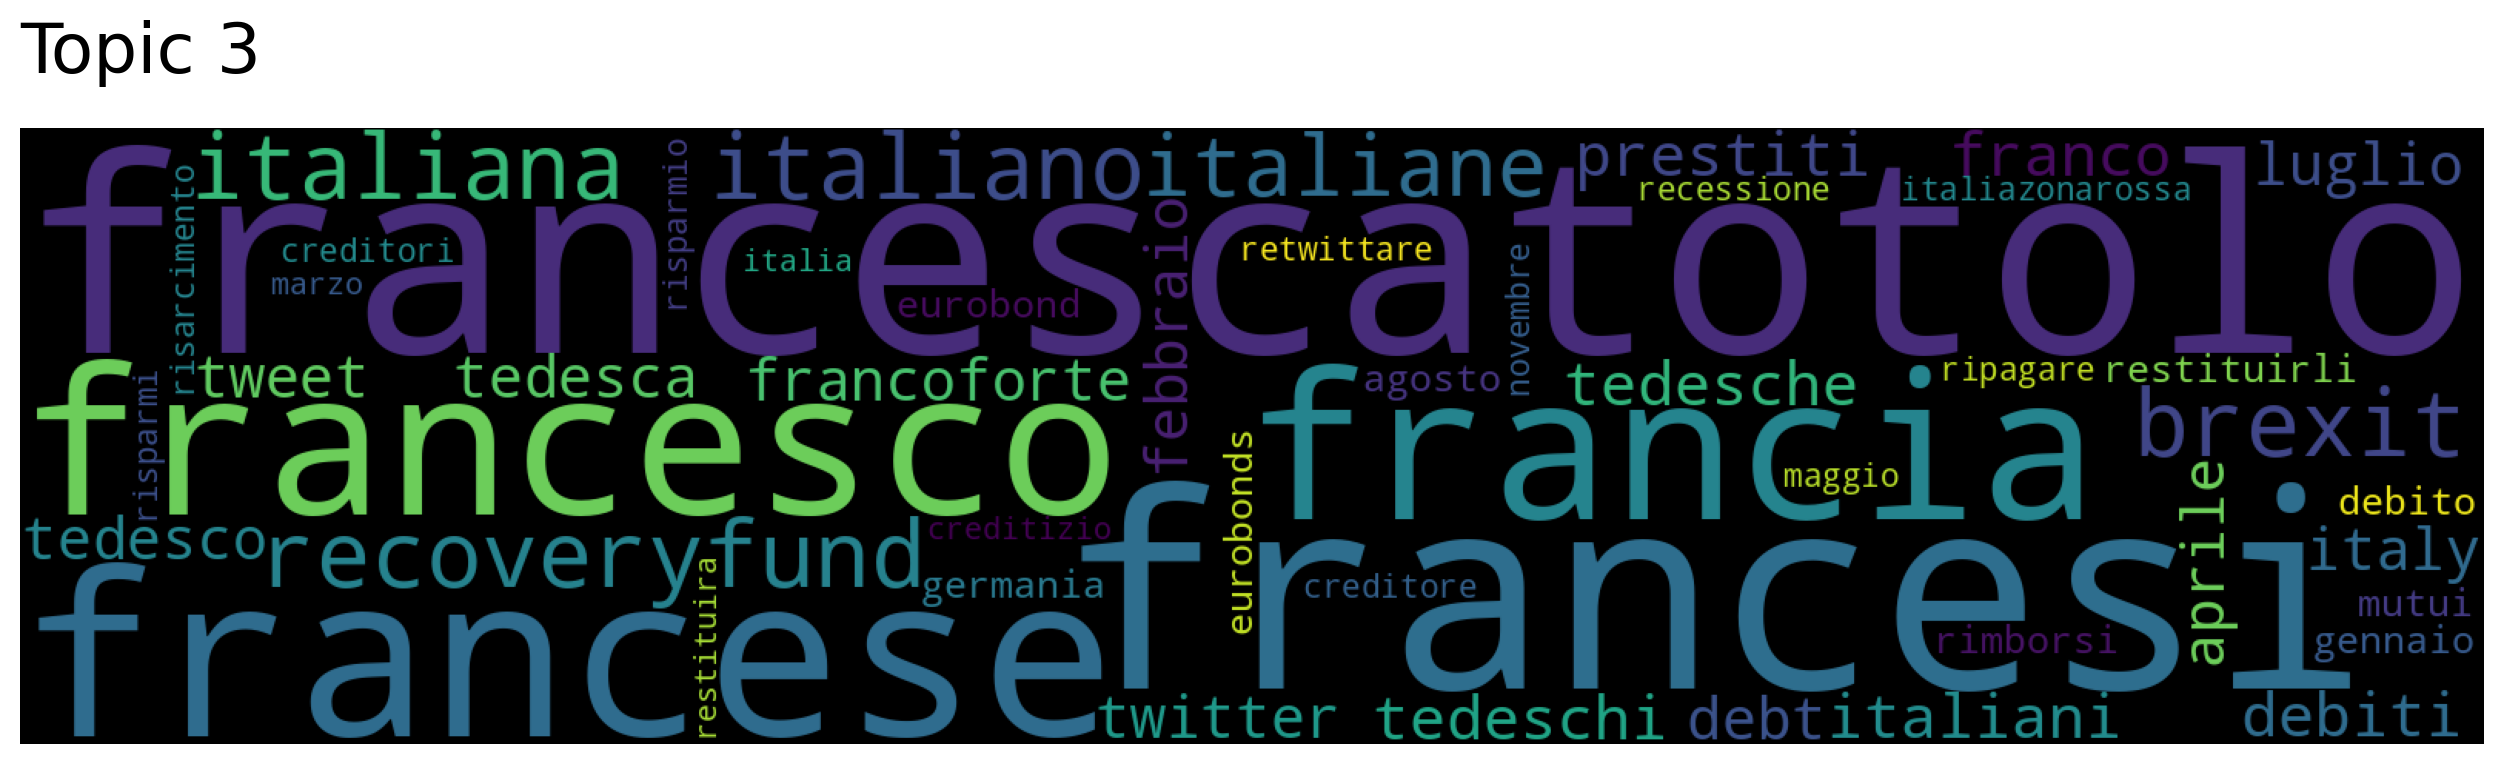

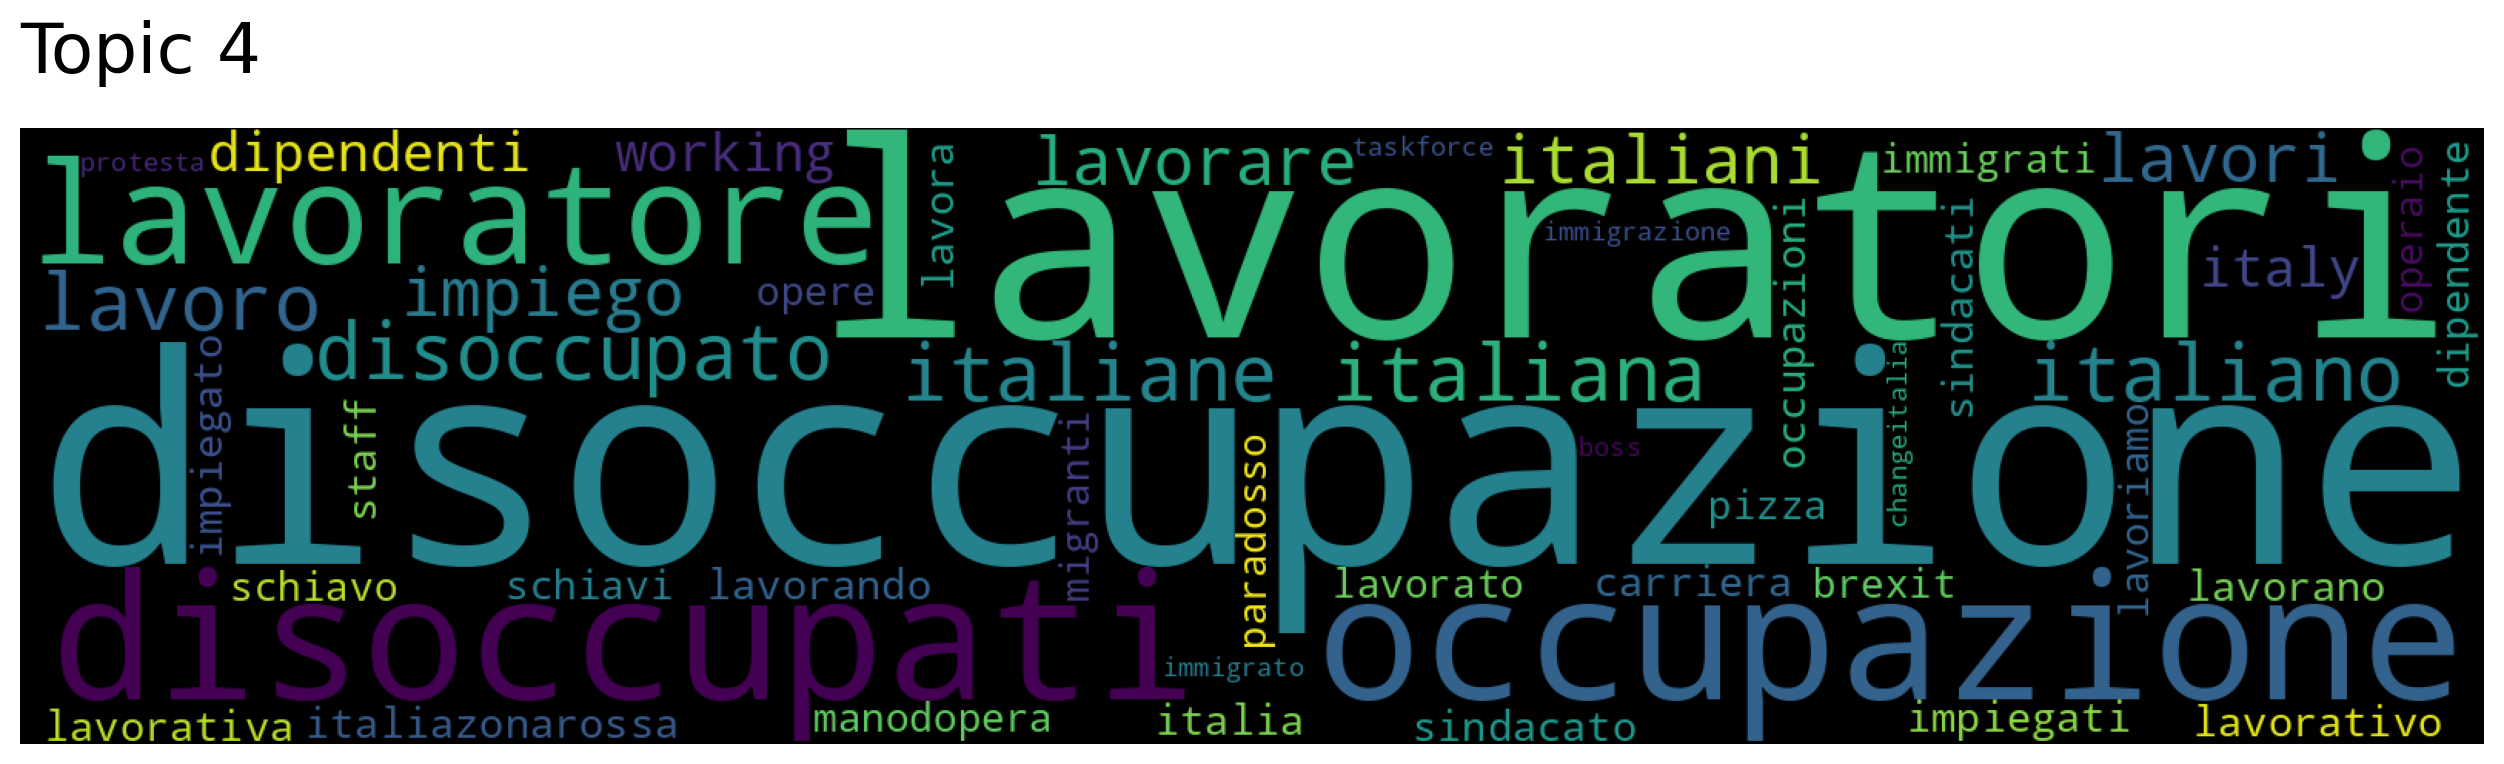

In [126]:
for topic in range(5):
    t2v_model.generate_topic_wordcloud(topic)

#### **Model coherence**

In [127]:
metrics = Metrics()
t2v_coherence = metrics.t2v_coherence(sentences, t2v_model.get_topics()[0])

print("Top2Vec Model Coherence: ", round(t2v_coherence, 5))

Top2Vec Model Coherence:  0.4248


<hr>

### **BERTopic**

In [128]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from torch import bfloat16
import transformers
from bertopic.representation import KeyBERTInspired, MaximalMarginalRelevance, TextGeneration

BERTopic leverages transformer-based embeddings to create document representations and applies clustering algorithms to discover topics. It combines BERT embeddings with clustering techniques like HDBSCAN and dimensionality reduction methods like UMAP to generate coherent topics from text data.

BERTopic involves the following steps:
1. **Embedding Creation**: BERTopic uses transformer models to create document embeddings.
2. **Dimensionality Reduction**: The embeddings are reduced in dimensionality using UMAP.
3. **Clustering**: Density-based clustering algorithm such as HDBSCAN are applied to form clusters from the reduced embeddings.
4. **Topic Representation**: The algorithm generates topics based on the clustered documents and their embeddings. In this step, LLMs can be used for automatic and meaningful topic labeling.

For more detailed information and examples, you can visit the [BERTopic documentation](https://maartengr.github.io/BERTopic).


#### **Model training (K-free)**
Let's start by training a K-free BERTopic model, i.e. we don't specify the number of topics we want to obtain. To prevent BERTopic from extracting too many topics, we can impose a condition on the minimum number of documents (Tweets) that a topic should include through the `min_topic_size` argument.

In [ ]:
# import the embedding_model
embeddings = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

# train the BERTopic model
min_topic_size = 30

BERTopic_model = BERTopic(
    embedding_model=embeddings,
    min_topic_size=min_topic_size,
    verbose=True
)
topics, probs = BERTopic_model.fit_transform(sentences)

#### **Topic visualization (K-free)**
The topic labeled as `-1` is a residual topic of documents BERTopic was not able to classify.

In [130]:
BERTopic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,2803,-1_di_che_il_non,"[di, che, il, non, per, la, un, in, le, del]",[la bufala del giorno riguarda il mes circola ...
1,0,2695,0_italia_di_la_che,"[italia, di, la, che, il, in, per, italiani, n...",[salvini è incredibile che domani ci siano mil...
2,1,1034,1_coronavirus_per_virus_il,"[coronavirus, per, virus, il, di, la, del, in,...",[la crisi coronavirus potrebbe far perdere più...
3,2,763,2_debito_banche_il_di,"[debito, banche, il, di, che, non, le, la, per...",[tutte le agenzie di stampa autorevoli ci stan...
4,3,381,3_economia_di_un_che,"[economia, di, un, che, la, non, per, in, il, ...",[io comunque pensavo di averle viste tutte ma ...
5,4,352,4_stipendio_non_lavoro_di,"[stipendio, non, lavoro, di, che, lo, mi, il, ...",[marattin donatalenzi massimogara quindi se pr...
6,5,248,5_sanità_medici_di_le,"[sanità, medici, di, le, per, spese, che, sani...",[spero che l esempio di infermieri medici e pe...
7,6,244,6_tasse_le_che_non,"[tasse, le, che, non, pagare, il, delle, per, ...","[marco dobbiamo pagare le tasse, luigidimaio a..."
8,7,242,7_prezzi_vendite_online_di,"[prezzi, vendite, online, di, amazon, per, in,...",[quando finirà questa situazione occorrerà che...
9,8,227,8_cittadinanza_reddito_di_il,"[cittadinanza, reddito, di, il, lavoro, che, p...",[chi percepisce il reddito di cittadinanza può...


BERTopic also includes hierarchical clustering.

In [131]:
hierarchical_topics = BERTopic_model.hierarchical_topics(sentences)
BERTopic_model.visualize_hierarchy(hierarchical_topics=hierarchical_topics)

100%|██████████| 28/28 [00:00<00:00, 209.22it/s]


#### **Model training (fixed K)**
We can force BERTopic to extract K Topics by setting an external Clustering Model.

In [ ]:
cluster_model = KMeans(n_clusters=20)

umap = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric='cosine',
    low_memory=False,
    random_state=seed
)

BERTopic_model = BERTopic(
    embedding_model=embeddings,
    umap_model=umap,
    min_topic_size=30,
    hdbscan_model=cluster_model,
    verbose=True
)
topics, probs = BERTopic_model.fit_transform(sentences)

#### **Topic visualization (fixed K)**

In [135]:
BERTopic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,0,1715,0_italia_di_italiani_in,"[italia, di, italiani, in, che, il, per, la, n...",[ci sono voluti morti di cui italiani per amme...
1,1,1076,1_coronavirus_per_il_di,"[coronavirus, per, il, di, la, virus, in, del,...",[io posso capire assolutamente il fatto che no...
2,2,1053,2_debito_il_banche_di,"[debito, il, banche, di, che, non, le, la, per...",[se anche le condizionalità che sono obbligato...
3,3,972,3_economia_di_che_un,"[economia, di, che, un, la, non, il, per, in, ma]",[io comunque pensavo di averle viste tutte ma ...
4,4,805,4_di_lavoro_non_che,"[di, lavoro, non, che, il, la, stipendio, per,...",[marattin donatalenzi massimogara quindi se pr...
5,5,712,5_prezzi_di_che_per,"[prezzi, di, che, per, in, vendite, la, non, i...",[oggi bce manda il povero philip lane a fare m...
6,6,600,6_di_la_che_per,"[di, la, che, per, europa, euro, il, non, in, un]",[la solidarietà europea in azione eu commissio...
7,7,581,7_tasse_le_di_non,"[tasse, le, di, non, che, il, per, la, un, in]",[lacla sono molte più le persone che seguono i...
8,8,569,8_di_il_che_la,"[di, il, che, la, euro, per, non, in, un, del]",[stopconinomi che ha fatto ha dichiarato lo st...
9,9,517,9_germania_la_di_in,"[germania, la, di, in, il, che, debito, per, n...",[la germania ha comprato tutti gli aeroporti d...


#### **Model coherence (fixed K)**

In [136]:
metrics = Metrics()
bert_coherence = metrics.bert_coherence(sentences, topics)

print("BERTopic Model Metrics (Coherence): ", round(bert_coherence, 5))

BERTopic Model Metrics (Coherence):  0.51043


**NOTE!** if you run under the recommended number of cluster of the original Bert Topic, the coherence will usually decrease!

#### **Topics reduction**
After fitting a BERTopic model, we can reduce the number of topics to a desired K.

In [ ]:
BERTopic_model.reduce_topics(sentences, nr_topics=10)

Visualize the reduced number of topics

In [138]:
BERTopic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,0,4732,0_di_che_il_non,"[di, che, il, non, la, per, le, un, in, del]",[un governo serio non imporrebbe mai a un impr...
1,1,2852,1_di_la_che_il,"[di, la, che, il, italia, per, in, non, un, it...",[ci sono voluti morti di cui italiani per amme...
2,2,1194,2_di_che_non_la,"[di, che, non, la, per, il, in, prezzi, un, le]",[ma visto il clima in cui viviamo c è davvero ...
3,3,1076,3_coronavirus_di_il_per,"[coronavirus, di, il, per, la, in, del, che, v...",[la crisi coronavirus potrebbe far perdere più...
4,4,46,4_courtesyas_ministro_rt_economia,"[courtesyas, ministro, rt, economia, da, suona...","[rt courtesyas ministro da economia [] , rt co..."
5,5,32,5_diegorusso_scacciavillani_pbiagiola_elia,"[diegorusso, scacciavillani, pbiagiola, elia, ...",[gianni elia usugo difesanimzo sandogat thecio...
6,6,26,6_ritwittate_drastico_prioritario_guidata,"[ritwittate, drastico, prioritario, guidata, t...",[auguri alla taskforce guidata da colao per la...
7,7,19,7_all_rosso_allarme_approvazione,"[all, rosso, allarme, approvazione, diffondere...",[allarme rosso all eurogruppo invece degli aiu...
8,8,13,8_diego_morto_aveva_svolgendo,"[diego, morto, aveva, svolgendo, anziano, chia...",[è morto a bergamo un operatore del aveva anni...
9,9,10,9_più_ha_democraticissima_rarissimo,"[più, ha, democraticissima, rarissimo, civilis...",[nella civilissima e democraticissima svezia d...


#### **Adding LLaMA-3 for topic labelling**
In order to run this part of the tutorial, you need to be running on a GPU compute (in colab, select **T4 GPU** as a runtime).

##### **Import LLaMA**
First of all, we need to import the `LLaMA-3-8B-Instruct` model and the relative tokenizer from huggingface 🤗. We will use a 4-bit quantized version of the model to improve efficiency.

In [ ]:
import accelerate

# Quantization to load an LLM with less GPU memory
bnb_config = transformers.BitsAndBytesConfig(
    load_in_4bit = True,
    bnb_4bit_quant_type = 'nf4',
    bnb_4bit_use_double_quant = True,
    bnb_4bit_compute_dtype = bfloat16
)

tokenizer = transformers.AutoTokenizer.from_pretrained(llm_model_id)

model = transformers.AutoModelForCausalLM.from_pretrained(
    llm_model_id,
    trust_remote_code = True,
    quantization_config = bnb_config,
    device_map = "auto",
)

generator = transformers.pipeline(
    model = model,
    tokenizer = tokenizer,
    task = 'text-generation',
    temperature = 0.1,
    max_new_tokens = 500,
    repetition_penalty = 1.1,
    return_full_text = False
)

##### **Prompt Structure**
This is where we tell our Large Language Model (LLM) how to label topics. There is no right way to do this, it's mostly a trial and error process. In this case, *few-shot* prompting (including examples in the prompt) could work better, experiment with it!

It is important to keep the structure of the prompt as specified in the [Llama 3 Model Card](https://llama.meta.com/docs/model-cards-and-prompt-formats/meta-llama-3/).

In [140]:
prompt_it = """<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Sei un assistente per l'etichettatura di topic ottenuti tramite Topic Modeling.<|eot_id|><|start_header_id|>user<|end_header_id|>

Ho un topic che contiene i seguenti documenti:
[DOCUMENTS]

Il topic è descritto dalle seguenti parole chiave: '[KEYWORDS]'.

Sulla base di queste informazioni, genera un'etichetta che descriva il topic. Genera SOLO l'etichetta e nient'altro.<|eot_id|><|start_header_id|>assistant"""

##### **Training**

In [141]:
embedding_model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")
embeddings = embedding_model.encode(sentences, show_progress_bar=True)

Batches:   0%|          | 0/313 [00:00<?, ?it/s]

In [143]:
umap = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric='cosine',
    low_memory=False,
    random_state=seed
)
reduced_embeddings = UMAP(n_components=2).fit_transform(embeddings)

In [144]:
keybert = KeyBERTInspired()

mmr = MaximalMarginalRelevance(diversity = 0.3)

llama3 = TextGeneration(generator, prompt=prompt_it)

representation_model = {
    "KeyBERT": keybert,
    "LLaMA3": llama3,
    "MMR": mmr,
}

Train the model and label the topics with LLaMA.

In [ ]:
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap,
    representation_model=representation_model,
    min_topic_size=30,
    verbose=True
)
topics, probs = topic_model.fit_transform(sentences, embeddings)

##### **Visualization**
BERTopic offers a wide range of visualization options. Check them out [here](https://maartengr.github.io/BERTopic/getting_started/visualization/visualization.html#visualize-probablities-or-distribution).

In [147]:
doc_info = topic_model.get_document_info(sentences)
allocation = doc_info[["Document", 'Topic']]

# clean the llama output
llama_labels = [x[0].lstrip('\n').split('\n')[0] for x in list(topic_model.get_topic_info()["LLaMA3"])]

results = topic_model.get_topic_info()[['Topic', 'Count', 'Representation', 'LLaMA3', 'Representative_Docs']]
results['LLaMA3'] = llama_labels

results.head(10)

,Topic,Count,Representation,LLaMA3,Representative_Docs
0,-1,2817,"[di, che, non, il, la, per, in, un, le, del]","""Politica economica e fake news""",[la bufala del giorno riguarda il mes circola ...
1,0,2651,"[italia, di, la, che, in, il, per, italiani, n...","""Politica economica italiana e UE""",[salvini è incredibile che domani ci siano mil...
2,1,984,"[coronavirus, per, virus, il, di, la, del, in,...","""Economia e Coronavirus""",[coronavirus ft ue prepara fondo anti disoccup...
3,2,502,"[stipendio, lavoro, non, di, che, mi, ho, il, ...","""Lavoro e salario""",[cioè io praticamente so solo che devo fare la...
4,3,495,"[economia, di, un, che, per, non, la, in, il, ...","""Economia pubblica e politiche economiche""",[io comunque pensavo di averle viste tutte ma ...
5,4,308,"[prezzi, vendite, di, acquistare, per, in, che...","""Acquisti e prezzi in mercato""",[poi fai la spesa ma sorpresa i prezzi sono au...
6,5,264,"[tasse, le, che, pagare, non, il, chi, per, de...","""Richiesta riduzione o sospensione delle tasse""","[marco dobbiamo pagare le tasse, rt maxkent gi..."
7,6,263,"[debito, pubblico, il, debiti, mes, di, del, c...","""Economia - Debito Pubblico""",[se anche le condizionalità che sono obbligato...
8,7,253,"[sanità, medici, di, le, per, spese, sanitarie...","""Topic sulla sanità pubblica e la gestione del...",[spero che l esempio di infermieri medici e pe...
9,8,245,"[cittadinanza, reddito, di, il, lavoro, per, c...","""Politica del reddito di cittadinanza e benefi...",[chi percepisce il reddito di cittadinanza può...


We can plot documents in a 2-dimensional space and color them according to their relative topic.

In [149]:
topic_model.set_topic_labels(llama_labels)

topic_model.visualize_documents(
    sentences,
    reduced_embeddings=reduced_embeddings,
    hide_annotations=True,
    hide_document_hover=False,
    custom_labels=True
)

Or we can plot an intertopic 2-dimensional distance map, where each circle represent a topic.

In [150]:
topic_model.visualize_topics()

This plot shows the most important words by topic.

In [151]:
topic_model.visualize_barchart()

While this heatmap shows the similarity between different topics.

In [152]:
topic_model.visualize_heatmap()

<hr>